1. Run all cells and the last cell will show the simulation interface. 
2. Generating simulation may take a few minutes. 
3. May need to adjust zoom/scroll to see the interface and play the simulation

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import random
import ipywidgets as widgets
from IPython.display import HTML, display, clear_output

In [23]:
class NaSchTrafficModel:    
    def __init__(self, num_lanes=1, road_length=100, max_velocity=5, 
                 density=0.2, p_slow=0.3, p_lane_change=0.5, 
                 p_slow_stopped=0.5, cell_length=7.5,
                 entry_probability=0.0):
        """
        Initialize the traffic model.
        
        Args:
            num_lanes : int
                Number of lanes (default: 1)
            road_length : int
                Number of cells in each lane (default: 100)
            max_velocity : int
                Maximum velocity in cells per timestep (default: 5)
            density : float
                Initial density of cars (0 to 1) (default: 0.2)
            p_slow : float
                Probability of random slowing for moving cars (default: 0.3)
            p_lane_change : float
                Probability of lane change when conditions are met (default: 0.5)
            p_slow_stopped : float
                Probability of random slowing for stopped cars (default: 0.5)
            cell_length : float
                Length of each cell in meters (default: 7.5)
            entry_probability : float
                Probability per timestep of a new car entering each lane at position 0
                (default: 0.0). Set > 0 to vary density over time for fundamental diagram.
        """
        self.num_lanes = num_lanes
        self.road_length = road_length
        self.max_velocity = max_velocity
        self.density = density
        self.p_slow = p_slow
        self.p_lane_change = p_lane_change
        self.p_slow_stopped = p_slow_stopped
        self.cell_length = cell_length
        self.entry_probability = entry_probability
        
        self.road = np.zeros((num_lanes, road_length, 2), dtype=int)
        
        self._initialize_cars()
        
        self.flow_history = []
        self.density_history = []
        self.average_velocity_history = []
        self.lane_flow_history = []  # Per-lane flow over time
        self.lane_density_history = []  # Per-lane density over time
        
    def _initialize_cars(self):
        """Initialize cars randomly on the road based on density."""
        total_cells = self.num_lanes * self.road_length
        num_cars = int(total_cells * self.density)
        
        all_positions = [(lane, pos) for lane in range(self.num_lanes) 
                        for pos in range(self.road_length)]
        car_positions = random.sample(all_positions, min(num_cars, len(all_positions)))
        
        for lane, pos in car_positions:
            self.road[lane, pos, 0] = 1
            self.road[lane, pos, 1] = random.randint(0, self.max_velocity)
    
    def _distance_to_next_car(self, lane, position):
        """
        Calculate distance (in cells) to the next car in the same lane.
        Returns distance (int) or road_length if no car ahead.
        """
        for d in range(1, self.road_length):
            next_pos = (position + d) % self.road_length
            if self.road[lane, next_pos, 0] == 1:
                return d
        return self.road_length
    
    def _space_in_adjacent_lane(self, lane, position):
        """
        Check if there is more space in adjacent lane.
        Returns True if adjacent lane has more empty cells ahead.
        """
        if self.num_lanes == 1:
            return False
            
        if lane > 0:
            left_space = 0
            for d in range(1, self.max_velocity + 1):
                next_pos = (position + d) % self.road_length
                if self.road[lane - 1, next_pos, 0] == 0:
                    left_space += 1
                else:
                    break
            current_space = 0
            for d in range(1, self.max_velocity + 1):
                next_pos = (position + d) % self.road_length
                if self.road[lane, next_pos, 0] == 0:
                    current_space += 1
                else:
                    break
            if left_space > current_space:
                return True
        
        # Check right lane (if exists)
        if lane < self.num_lanes - 1:
            right_space = 0
            for d in range(1, self.max_velocity + 1):
                next_pos = (position + d) % self.road_length
                if self.road[lane + 1, next_pos, 0] == 0:
                    right_space += 1
                else:
                    break
            current_space = 0
            for d in range(1, self.max_velocity + 1):
                next_pos = (position + d) % self.road_length
                if self.road[lane, next_pos, 0] == 0:
                    current_space += 1
                else:
                    break
            if right_space > current_space:
                return True
        
        return False
    
    def _can_change_lane_safely(self, lane, position, target_lane, velocity):
        """
        Check if changing lanes is safe (won't cause rear-end collision).
        """
        if target_lane < 0 or target_lane >= self.num_lanes:
            return False
        
        if self.road[target_lane, position, 0] == 1:
            return False  # Cell occupied
        
        for d in range(1, velocity + 1):
            behind_pos = (position - d) % self.road_length
            if self.road[target_lane, behind_pos, 0] == 1:
                # Car behind might hit us if we change lanes
                behind_velocity = self.road[target_lane, behind_pos, 1]
                if behind_velocity >= d:  # Car behind could reach our position
                    return False
        
        return True
    
    def update(self):
        """
        Update the traffic model for one timestep.
        Returns the number of cars that passed the end of the road.
        """
        new_road = np.zeros_like(self.road)
        cars_passed = 0
        cars_passed_per_lane = [0] * self.num_lanes
        
        decisions = []
        
        for lane in range(self.num_lanes):
            for position in range(self.road_length):
                if self.road[lane, position, 0] == 1:
                    velocity = self.road[lane, position, 1]
                    
                    new_velocity = min(velocity + 1, self.max_velocity)
                    
                    distance = self._distance_to_next_car(lane, position)
                    new_velocity = min(new_velocity, distance - 1)
                    
                    if new_velocity > 0:
                        if random.random() < self.p_slow:
                            new_velocity = max(0, new_velocity - 1)
                    else:  
                        if random.random() < self.p_slow_stopped:
                            new_velocity = 0  
                            
                    lane_change = False
                    target_lane = lane
                    
                    if self.num_lanes > 1:
                        motivation = (new_velocity > distance - 1) and self._space_in_adjacent_lane(lane, position)
                        
                        if motivation:
                            possible_lanes = []
                            if lane > 0 and self._can_change_lane_safely(lane, position, lane - 1, new_velocity):
                                possible_lanes.append(lane - 1)
                            if lane < self.num_lanes - 1 and self._can_change_lane_safely(lane, position, lane + 1, new_velocity):
                                possible_lanes.append(lane + 1)
                            
                            if possible_lanes and random.random() < self.p_lane_change:
                                lane_change = True
                                target_lane = random.choice(possible_lanes)
                    
                    decisions.append({
                        'old_lane': lane,
                        'old_position': position,
                        'new_lane': target_lane if lane_change else lane,
                        'new_position': (position + new_velocity) % self.road_length,
                        'new_velocity': new_velocity,
                        'lane_change': lane_change
                    })
        
        # Second pass: apply movements (all cars move simultaneously)
        for decision in decisions:
            old_lane = decision['old_lane']
            old_position = decision['old_position']
            new_lane = decision['new_lane']
            new_position = decision['new_position']
            new_velocity = decision['new_velocity']
            
            if new_position < old_position:
                cars_passed += 1
                cars_passed_per_lane[old_lane] += 1
            
            # Move car to new position
            new_road[new_lane, new_position, 0] = 1
            new_road[new_lane, new_position, 1] = new_velocity
        
        # Update road state
        self.road = new_road
        
        # Add new cars at position 0 based on entry_probability
        if self.entry_probability > 0:
            for lane in range(self.num_lanes):
                if self.road[lane, 0, 0] == 0 and random.random() < self.entry_probability:
                    self.road[lane, 0, 0] = 1
                    self.road[lane, 0, 1] = random.randint(0, self.max_velocity)
        
        # Update statistics
        self._update_statistics(cars_passed, cars_passed_per_lane)
        
        return cars_passed
    
    def _update_statistics(self, cars_passed, cars_passed_per_lane=None):
        """Update flow, density, and average velocity statistics.
        
        Flow is calculated using the fundamental relation: flow = density × velocity
        This gives flow in veh/step/lane, which is a continuous value (not just integers).
        
        Args:
            cars_passed: Total number of cars that passed the end of the road
            cars_passed_per_lane: List of cars that passed per lane (veh/step)
        """
        total_cars = np.sum(self.road[:, :, 0])
        current_density = total_cars / (self.num_lanes * self.road_length)
        
        moving_cars = self.road[:, :, 0] * self.road[:, :, 1]
        total_velocity = np.sum(moving_cars)
        if total_cars > 0:
            avg_velocity = total_velocity / total_cars
        else:
            avg_velocity = 0
        
        # Flow = density × avg_velocity (fundamental relation of traffic flow)
        # This gives flow in veh/step/lane
        current_flow = current_density * avg_velocity
        
        # Store history
        self.flow_history.append(current_flow)
        self.density_history.append(current_density)
        self.average_velocity_history.append(avg_velocity)
        
        # Track per-lane statistics
        lane_densities = []
        lane_flows = []
        for lane in range(self.num_lanes):
            lane_cars = np.sum(self.road[lane, :, 0])
            lane_density = lane_cars / self.road_length
            lane_densities.append(lane_density)
            
            # Per-lane flow = lane_density × avg velocity in that lane
            lane_velocities = self.road[lane, :, 0] * self.road[lane, :, 1]
            lane_total_vel = np.sum(lane_velocities)
            lane_avg_vel = lane_total_vel / lane_cars if lane_cars > 0 else 0
            lane_flows.append(lane_density * lane_avg_vel)
        
        self.lane_density_history.append(lane_densities)
        self.lane_flow_history.append(lane_flows)
    
    def get_statistics(self):
        """Get current statistics."""
        return {
            'flow': self.flow_history[-1] if self.flow_history else 0,
            'density': self.density_history[-1] if self.density_history else 0,
            'avg_velocity': self.average_velocity_history[-1] if self.average_velocity_history else 0,
            'total_cars': np.sum(self.road[:, :, 0])
        }

In [24]:
class TrafficVisualizer:    
    def __init__(self, model, figsize=(14, 10)):
        self.model = model
        # Use GridSpec for custom layout: big road on top, 4 graphs below
        self.fig = plt.figure(figsize=figsize)
        gs = self.fig.add_gridspec(2, 1, height_ratios=[1.2, 1], hspace=0.3)
        
        # Top: Road visualization (tall)
        self.ax_road = self.fig.add_subplot(gs[0, 0])
        
        # Bottom: 2x2 grid of graphs
        gs_bottom = gs[1, 0].subgridspec(2, 2, hspace=0.5, wspace=0.3)
        self.ax_velocity_dist = self.fig.add_subplot(gs_bottom[0, 0])
        self.ax_avg_velocity = self.fig.add_subplot(gs_bottom[0, 1])
        self.ax_lane_flow = self.fig.add_subplot(gs_bottom[1, 0])
        self.ax_lane_density = self.fig.add_subplot(gs_bottom[1, 1])
        
        self.frames = []
        self._setup_plots()
        
    def _setup_plots(self):
        """Set up the initial plot structure."""
        # Plot 1: Road visualization (big, top)
        self.road_display = np.zeros((self.model.num_lanes, self.model.road_length))
        self.im = self.ax_road.imshow(self.road_display, cmap='viridis', aspect='auto', 
                                      interpolation='nearest', vmin=0, vmax=self.model.max_velocity + 1)
        self.ax_road.set_title('Traffic Simulation')
        self.ax_road.set_xlabel('Position (cells)')
        self.ax_road.set_ylabel('Lane')
        self.colorbar = plt.colorbar(self.im, ax=self.ax_road, label='Velocity + 1')
        
        # Plot 2: Velocity distribution
        self.ax_velocity_dist.set_xlabel('Velocity (cells/timestep)')
        self.ax_velocity_dist.set_ylabel('Number of cars')
        self.ax_velocity_dist.set_title('Velocity Distribution')
        self.ax_velocity_dist.set_xticks(range(self.model.max_velocity + 1))
        
        # Plot 3: Average velocity over time
        self.ax_avg_velocity.set_xlabel('Time (timesteps)')
        self.ax_avg_velocity.set_ylabel('Avg Velocity (cells/timestep)')
        self.ax_avg_velocity.set_title('Average Velocity Over Time')
        self.ax_avg_velocity.grid(True, alpha=0.3)
        self.ax_avg_velocity.set_ylim(0, self.model.max_velocity)
        
        # Plot 4: Per-lane flow over time
        self.ax_lane_flow.set_xlabel('Time (timesteps)')
        self.ax_lane_flow.set_ylabel('Flow (veh/step)')
        self.ax_lane_flow.set_title('Per-Lane Flow Over Time')
        self.ax_lane_flow.grid(True, alpha=0.3)
        
        # Plot 5: Per-lane density over time
        self.ax_lane_density.set_xlabel('Time (timesteps)')
        self.ax_lane_density.set_ylabel('Density (cars/cell)')
        self.ax_lane_density.set_title('Per-Lane Density Over Time')
        self.ax_lane_density.grid(True, alpha=0.3)
        self.ax_lane_density.set_ylim(0, 1)
        
    def visualize_frame(self, frame_num):
        """Visualize a single frame of the simulation by updating plot data."""
        # Update Plot 1: Road visualization (big, top)
        self.road_display.fill(0)
        for lane in range(self.model.num_lanes):
            for pos in range(self.model.road_length):
                if self.model.road[lane, pos, 0] == 1:
                    velocity = self.model.road[lane, pos, 1]
                    self.road_display[lane, pos] = velocity + 1
        self.im.set_data(self.road_display)
        self.ax_road.set_title(f'Traffic Simulation (Frame {frame_num})')
        
        # Update Plot 2: Velocity distribution
        velocities = []
        for lane in range(self.model.num_lanes):
            for pos in range(self.model.road_length):
                if self.model.road[lane, pos, 0] == 1:
                    velocities.append(self.model.road[lane, pos, 1])
        
        self.ax_velocity_dist.cla()
        self.ax_velocity_dist.set_xlabel('Velocity (cells/timestep)')
        self.ax_velocity_dist.set_ylabel('Number of cars')
        self.ax_velocity_dist.set_title('Velocity Distribution')
        self.ax_velocity_dist.set_xticks(range(self.model.max_velocity + 1))
        if velocities:
            self.ax_velocity_dist.hist(velocities, bins=range(self.model.max_velocity + 2), 
                                       alpha=0.7, edgecolor='black')
        
        # Update Plot 3: Average velocity over time
        self.ax_avg_velocity.cla()
        self.ax_avg_velocity.set_xlabel('Time (timesteps)')
        self.ax_avg_velocity.set_ylabel('Avg Velocity (cells/timestep)')
        self.ax_avg_velocity.set_title('Average Velocity Over Time')
        self.ax_avg_velocity.grid(True, alpha=0.3)
        self.ax_avg_velocity.set_ylim(0, self.model.max_velocity)
        if len(self.model.average_velocity_history) > 0:
            self.ax_avg_velocity.plot(self.model.average_velocity_history, 'b-', linewidth=2)
        
        # Update Plot 4: Per-lane flow over time
        self.ax_lane_flow.cla()
        self.ax_lane_flow.set_xlabel('Time (timesteps)')
        self.ax_lane_flow.set_ylabel('Flow (veh/step)')
        self.ax_lane_flow.set_title('Per-Lane Flow Over Time')
        self.ax_lane_flow.grid(True, alpha=0.3)
        if len(self.model.lane_flow_history) > 0:
            colors = plt.cm.tab10(np.linspace(0, 1, self.model.num_lanes))
            for lane in range(self.model.num_lanes):
                lane_flow = [t[lane] for t in self.model.lane_flow_history]
                self.ax_lane_flow.plot(lane_flow, color=colors[lane], linewidth=2, 
                                       label=f'Lane {lane+1}')
            self.ax_lane_flow.legend(fontsize=8)
        
        # Update Plot 5: Per-lane density over time
        self.ax_lane_density.cla()
        self.ax_lane_density.set_xlabel('Time (timesteps)')
        self.ax_lane_density.set_ylabel('Density (cars/cell)')
        self.ax_lane_density.set_title('Per-Lane Density Over Time')
        self.ax_lane_density.grid(True, alpha=0.3)
        self.ax_lane_density.set_ylim(0, 1)
        if len(self.model.lane_density_history) > 0:
            colors = plt.cm.tab10(np.linspace(0, 1, self.model.num_lanes))
            for lane in range(self.model.num_lanes):
                lane_density = [t[lane] for t in self.model.lane_density_history]
                self.ax_lane_density.plot(lane_density, color=colors[lane], linewidth=2, 
                                          label=f'Lane {lane+1}')
            self.ax_lane_density.legend(fontsize=8)
        
        # Save rendered frame for animation
        import io
        from PIL import Image as PILImage
        buf = io.BytesIO()
        self.fig.savefig(buf, format='png', bbox_inches='tight')
        buf.seek(0)
        self.frames.append(np.array(PILImage.open(buf)))
    
    def create_animation(self, num_frames=100, interval=200):
        """Create and display animation."""
        for i in range(num_frames):
            self.model.update()
            self.visualize_frame(i)
        
        from matplotlib.animation import ArtistAnimation
        # Create animation from saved frame images
        anim_fig, anim_ax = plt.subplots(figsize=(14, 10))
        anim_ax.axis('off')
        artists = []
        for frame_array in self.frames:
            artists.append([anim_ax.imshow(frame_array, animated=True)])
        animation = ArtistAnimation(anim_fig, artists, interval=interval, blit=False)
        return animation

In [25]:
def create_interactive_simulation():
    """Create an interactive simulation with widgets."""
    num_lanes_slider = widgets.IntSlider(
        value=3, min=1, max=5, step=1, 
        description='Number of lanes:',
        style={'description_width': 'initial'}
    )
    
    road_length_slider = widgets.IntSlider(
        value=50, min=20, max=200, step=10,
        description='Road length (cells):',
        style={'description_width': 'initial'}
    )
    
    max_velocity_slider = widgets.IntSlider(
        value=5, min=1, max=10, step=1,
        description='Max velocity:',
        style={'description_width': 'initial'}
    )
    
    density_slider = widgets.FloatSlider(
        value=0.2, min=0.05, max=0.8, step=0.05,
        description='Initial density:',
        style={'description_width': 'initial'}
    )
    
    p_slow_slider = widgets.FloatSlider(
        value=0.01, min=0.0, max=0.3, step=0.01,
        description='P(slow) moving:',
        style={'description_width': 'initial'}
    )
    
    p_slow_stopped_slider = widgets.FloatSlider(
        value=0.5, min=0.0, max=1.0, step=0.05,
        description='P(slow) stopped:',
        style={'description_width': 'initial'}
    )
    
    p_lane_change_slider = widgets.FloatSlider(
        value=0.5, min=0.0, max=1.0, step=0.05,
        description='P(lane change):',
        style={'description_width': 'initial'}
    )
    
    entry_probability_slider = widgets.FloatSlider(
        value=0.3, min=0.0, max=0.8, step=0.05,
        description='Entry probability:',
        style={'description_width': 'initial'}
    )
    
    num_frames_slider = widgets.IntSlider(
        value=100, min=10, max=500, step=10,
        description='Animation frames:',
        style={'description_width': 'initial'}
    )
    
    run_button = widgets.Button(
        description='Run Simulation',
        button_style='success',
        tooltip='Run the simulation with current parameters'
    )
    
    reset_button = widgets.Button(
        description='Reset Simulation',
        button_style='warning',
        tooltip='Reset the simulation to initial state'
    )
    
    output = widgets.Output()
    
    def run_simulation(button):
        """Run the simulation with current parameters."""
        with output:
            clear_output(wait=True)
            
            # Show loading indicator
            loading_html = """
            <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; padding: 40px;">
                <div style="border: 4px solid #f3f3f3; border-top: 4px solid #3498db; border-radius: 50%; width: 40px; height: 40px; animation: spin 1s linear infinite;"></div>
                <p style="margin-top: 16px; font-family: sans-serif; color: #555;">Generating simulation...</p>
            </div>
            <style>
                @keyframes spin { 0% { transform: rotate(0deg); } 100% { transform: rotate(360deg); } }
            </style>
            """
            display(HTML(loading_html))
            
            # Create model with current parameters
            model = NaSchTrafficModel(
                num_lanes=num_lanes_slider.value,
                road_length=road_length_slider.value,
                max_velocity=max_velocity_slider.value,
                density=density_slider.value,
                p_slow=p_slow_slider.value,
                p_lane_change=p_lane_change_slider.value,
                p_slow_stopped=p_slow_stopped_slider.value,
                entry_probability=entry_probability_slider.value
            )
            
            visualizer = TrafficVisualizer(model)
            animation = visualizer.create_animation(
                num_frames=num_frames_slider.value,
                interval=200
            )
            
            # Clear loading indicator and display animation
            clear_output(wait=True)
            
            # Display animation - try to_jshtml first, fall back to to_html5_video
            try:
                display(HTML(animation.to_jshtml()))
            except AttributeError:
                # Fallback for non-interactive backends (e.g., Agg)
                display(HTML(animation.to_html5_video()))
            
            # Display statistics
            stats = model.get_statistics()
            print(f"Simulation Statistics")
            print(f"{'='*40}")
            print(f"  Final state:")
            print(f"    Total cars:     {stats['total_cars']}")
            print(f"    Density:        {stats['density']:.3f} cars/cell")
            print(f"    Avg velocity:   {stats['avg_velocity']:.2f} cells/step")
            print(f"    Flow (last):    {stats['flow']:.3f} veh/step/ln")
            
            # Show history summary
            if len(model.density_history) > 1:
                print(f"\n  Over {len(model.density_history)} timesteps:")
                print(f"    Density:        {min(model.density_history):.3f} min, {max(model.density_history):.3f} max, {np.mean(model.density_history):.3f} avg")
                print(f"    Avg velocity:   {min(model.average_velocity_history):.2f} min, {max(model.average_velocity_history):.2f} max, {np.mean(model.average_velocity_history):.2f} avg")
                print(f"    Flow:           {min(model.flow_history):.3f} min, {max(model.flow_history):.3f} max, {np.mean(model.flow_history):.3f} avg veh/step/ln")
                
                # Show a sample of timesteps (first 5 and last 5)
                n = len(model.density_history)
                print(f"\n  Timestep progression (first 5):")
                print(f"    {'Step':>5} {'Density':>8} {'Velocity':>9} {'Flow':>8}")
                print(f"    {'-'*33}")
                for i in range(min(5, n)):
                    print(f"    {i+1:>5} {model.density_history[i]:>8.3f} {model.average_velocity_history[i]:>9.2f} {model.flow_history[i]:>8.3f}")
                if n > 10:
                    print(f"    {'...':>5} {'...':>8} {'...':>9} {'...':>8}")
                    for i in range(max(5, n-5), n):
                        print(f"    {i+1:>5} {model.density_history[i]:>8.3f} {model.average_velocity_history[i]:>9.2f} {model.flow_history[i]:>8.3f}")
    
    def reset_simulation(button):
        """Reset the simulation output."""
        with output:
            clear_output(wait=True)
            print("Simulation reset. Adjust parameters and click 'Run Simulation'.")
    
    # Connect button events
    run_button.on_click(run_simulation)
    reset_button.on_click(reset_simulation)
    
    # Create layout
    controls = widgets.VBox([
        widgets.HTML("<h3>Simulation Parameters</h3>"),
        num_lanes_slider,
        road_length_slider,
        max_velocity_slider,
        density_slider,
        p_slow_slider,
        p_slow_stopped_slider,
        p_lane_change_slider,
        entry_probability_slider,
        num_frames_slider,
        widgets.HBox([run_button, reset_button])
    ])
    
    display(widgets.VBox([controls, output]))
    
    with output:
        print("Adjust parameters above and click 'Run Simulation' to start.")

In [26]:
def run_demo():
    """Run a demo simulation with default parameters."""
    print("NaSch Traffic Model Demo")
    print("========================")
    
    # Create model
    model = NaSchTrafficModel(
        num_lanes=2,
        road_length=50,
        max_velocity=5,
        density=0.3,
        p_slow=0.3,
        p_lane_change=0.5,
        p_slow_stopped=0.5
    )
    
    # Run simulation for a few steps
    print("Running simulation for 10 timesteps...")
    for i in range(10):
        cars_passed = model.update()
        stats = model.get_statistics()
        print(f"Timestep {i+1}: Flow={cars_passed}, Density={stats['density']:.3f}, Avg Velocity={stats['avg_velocity']:.2f}")
    
    print("\nCreating animation...")
    visualizer = TrafficVisualizer(model)
    animation = visualizer.create_animation(num_frames=50, interval=200)
    
    # Display animation - try to_jshtml first, fall back to to_html5_video
    try:
        display(HTML(animation.to_jshtml()))
    except AttributeError:
        # Fallback for non-interactive backends (e.g., Agg)
        display(HTML(animation.to_html5_video()))
    
    return model, visualizer

In [27]:
if __name__ == "__main__":
    # This allows the file to be run as a script
    print("NaSch Traffic Cellular Automata")
    print("================================")
    print("This file is designed to be run in a Jupyter notebook.")
    print("To use interactively:")
    print("1. Run: create_interactive_simulation()")
    print("2. Or run: run_demo()")
    print("\nFor command-line testing, you can run a simple simulation:")
    
    # Simple command-line test
    model = NaSchTrafficModel(num_lanes=1, road_length=20, density=0.3)
    print("\nSimple test simulation (1 lane, 20 cells, 30% density):")
    for i in range(5):
        cars_passed = model.update()
        print(f"Timestep {i+1}: {cars_passed} cars passed")

NaSch Traffic Cellular Automata
This file is designed to be run in a Jupyter notebook.
To use interactively:
1. Run: create_interactive_simulation()
2. Or run: run_demo()

For command-line testing, you can run a simple simulation:

Simple test simulation (1 lane, 20 cells, 30% density):
Timestep 1: 0 cars passed
Timestep 2: 0 cars passed
Timestep 3: 1 cars passed
Timestep 4: 0 cars passed
Timestep 5: 1 cars passed


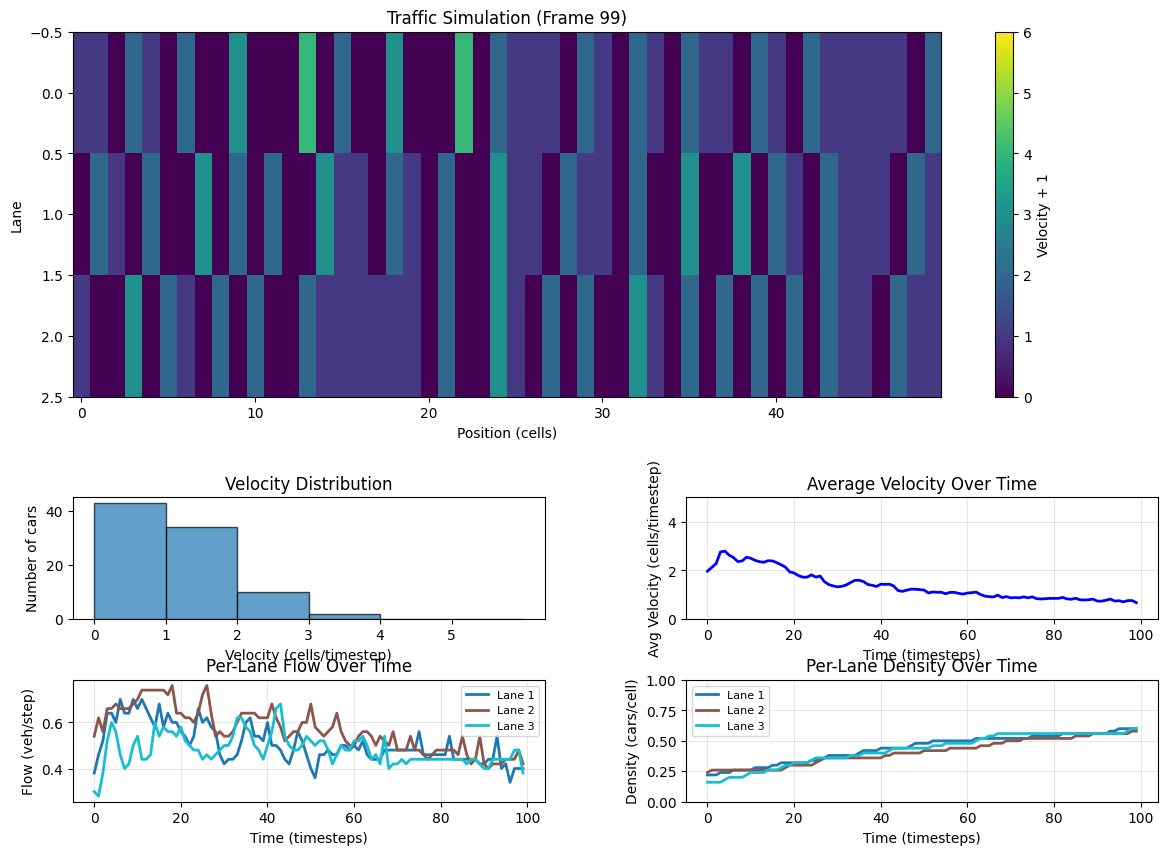

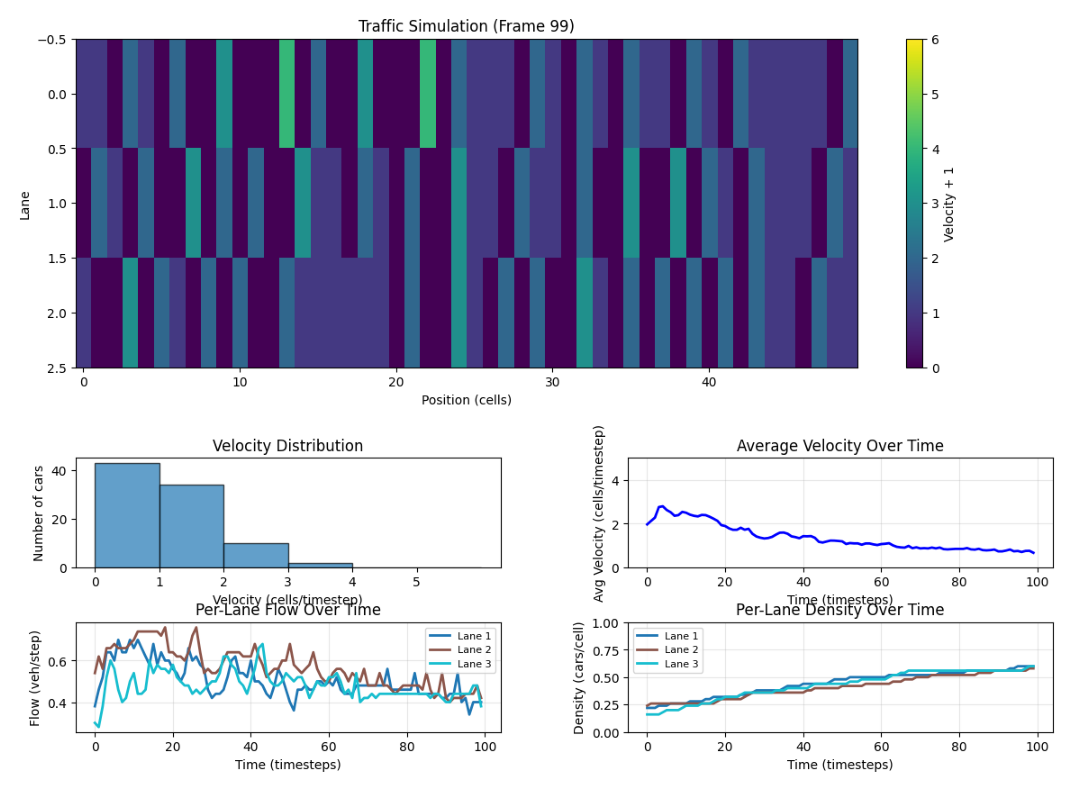

In [28]:
create_interactive_simulation()